In [2]:
!pip install sigpy

  Using cached sigpy-0.1.27-1-py3-none-any.whl.metadata (5.1 kB)
  Using cached pywavelets-1.9.0-cp313-cp313-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (7.6 kB)
  Using cached numba-0.63.1-cp313-cp313-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (2.9 kB)
  Using cached llvmlite-0.46.0-cp313-cp313-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (5.0 kB)
  Using cached numpy-2.3.5-cp313-cp313-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (62 kB)
Using cached sigpy-0.1.27-1-py3-none-any.whl (108 kB)
Using cached numba-0.63.1-cp313-cp313-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (3.8 MB)
Using cached llvmlite-0.46.0-cp313-cp313-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (56.3 MB)
Using cached numpy-2.3.5-cp313-cp313-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (16.6 MB)
Using cached pywavelets-1.9.0-cp313-cp313-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (4.5 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy

In [ ]:
import sigpy as sp
import sigpy.mri as mr
import sigpy.plot as pl
import numpy as np

# 1. Setup Device
# device = -1 explicitly tells SigPy to use the CPU
device = sp.Device(-1)
print(f"✅ Using Device: {device} (CPU)")

# 2. Simulate Data (Multi-channel K-space)
img_shape = [128, 128]
num_coils = 8

print("Simulating phantom data...")
# Generate phantom and coil sensitivities
phantom = sp.shepp_logan(img_shape)
sens_true = mr.birdcage_maps((num_coils, *img_shape))
img_multicoil = phantom * sens_true

# Transform to k-space (FFT)
# We add some noise to make it realistic
kspace = sp.fft(img_multicoil, axes=(-2, -1))
noise = np.random.randn(*kspace.shape) + 1j * np.random.randn(*kspace.shape)
kspace = kspace + 0.001 * noise

# 3. Run ESPIRiT Calibration
# Note: On CPU, this might take a few seconds for larger matrices.
print("Starting ESPIRiT calibration on CPU...")

app = mr.app.EspiritCalib(
    kspace, 
    calib_width=24,   # Size of the auto-calibration region
    thresh=0.02,      # Threshold for the eigenvalue mask
    kernel_width=6,   # Kernel size
    crop=0.95,        # Field of view cropping
    max_iter=30,      # Power method iterations
    device=device,    # -1 for CPU
    show_pbar=True
)

# .run() executes the algorithm
maps = app.run()

print("Calibration complete.")

# 4. Visualization
# We use sigpy.plot directly. 
# Depending on your environment (Jupyter vs Terminal), this opens a window.
pl.ImagePlot(
    maps, 
    z=0, 
    title='Estimated Sensitivity Maps (Magnitude)',
    mode='m',  # 'm' for magnitude
)

/home/biswamitra/health/yash/miniconda3/envs/biswa_env/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading /home/biswamitra/health/knee_data/train/deconstructed_train/file1000001_015.npy...
Data Shape: (15, 640, 368)
Starting ESPIRiT calibration (this may take ~10-30 seconds on CPU)...


EspiritCalib: 100%|██████████| 100/100 [00:08<00:00, 12.27it/s]


Calibration complete. type of sensitivity maps :  (15, 640, 368) <class 'numpy.ndarray'>


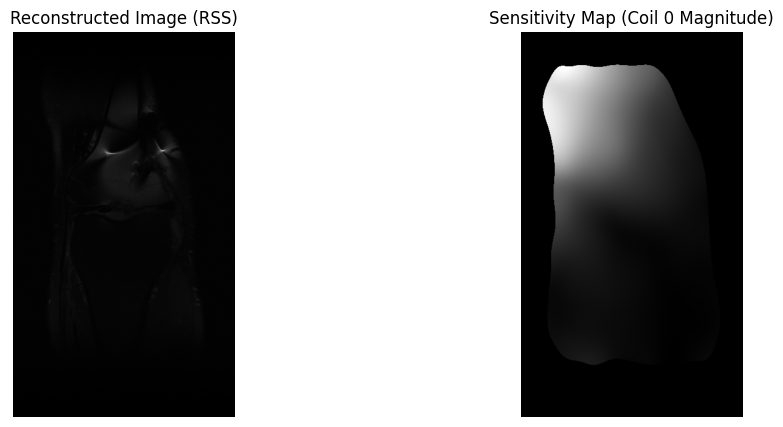

In [1]:
import numpy as np
import sigpy as sp
import sigpy.mri as mr
import matplotlib.pyplot as plt

# 1. Load the Data
file_path = '/home/biswamitra/health/knee_data/train/deconstructed_train/file1000001_015.npy'
print(f"Loading {file_path}...")
kspace = np.load(file_path)

# Ensure data is complex-valued (FastMRI data usually is)
if not np.iscomplexobj(kspace):
    print("Warning: Data is not complex! Check if real/imag are split.")

print(f"Data Shape: {kspace.shape}")  # Should be (num_coils, x, y)

# 2. Sanity Check: Reconstruct the Image (RSS)
# We perform an Inverse FFT (IFFT) to see what the MRI slice actually looks like.
# axes=(-2, -1) tells it to transform the last two dimensions (x, y).
img_multicoil = sp.ifft(kspace, axes=(-2, -1))

# Root-Sum-of-Squares combines all coils into one viewing image
rss_image = sp.rss(img_multicoil, axes=0)

# 3. Run ESPIRiT Calibration (CPU Mode)
print("Starting ESPIRiT calibration (this may take ~10-30 seconds on CPU)...")

# FastMRI knee data often has a large Field of View. 
# We adjust 'crop' to 0.95 to focus on the anatomy and ignore edge noise.
app = mr.app.EspiritCalib(
    kspace, 
    calib_width=24,    # Center region used for auto-calibration
    thresh=0.02,       # Background threshold
    kernel_width=6,    # Standard kernel size
    crop=0.95,         # 0.95 is standard for data with no oversampling
    device=sp.Device(-1), # CPU execution
    show_pbar=True
)

sensitivity_maps = app.run()
print("Calibration complete. type of sensitivity maps : ", sensitivity_maps.shape, type(sensitivity_maps))

# 4. Visualization
# We will plot the RSS image (Anatomy) and the First Coil's Sensitivity Map
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Plot Anatomy (RSS)
ax[0].imshow(np.abs(rss_image), cmap='gray')
ax[0].set_title("Reconstructed Image (RSS)")
ax[0].axis('off')

# Plot Sensitivity Map (Coil 0 Magnitude)
# We show only the 0-th coil map for brevity
ax[1].imshow(np.abs(sensitivity_maps[0]), cmap='gray')
ax[1].set_title("Sensitivity Map (Coil 0 Magnitude)")
ax[1].axis('off')

plt.show()

# Optional: Save the maps
# np.save('sensitivity_maps.npy', sensitivity_maps)

In [2]:
print(type(sensitivity_maps[0][0][0]))

<class 'numpy.complex64'>
